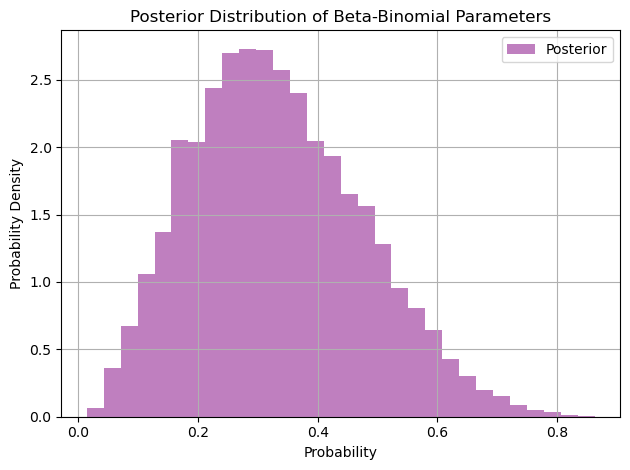

In [1]:
import numpy as np
from scipy.stats import beta, binom
import matplotlib.pyplot as plt

# Step 1: Initialize parameters
alpha_initial = 1.0
beta_initial = 2.0

# Step 2: E-step (Expectation)
def calculate_expected_values(data, alpha, beta):
    expected_values = []
    for observation in data:
        expected_value = alpha / (alpha + beta)
        expected_values.append(expected_value)
    return expected_values

# Step 3: M-step (Maximization)
def update_parameters(data, expected_values):
    alpha_updated = np.sum(expected_values)
    beta_updated = len(data) - alpha_updated
    return alpha_updated, beta_updated

# Step 4: Convergence criterion
def has_converged(alpha_prev, beta_prev, alpha_updated, beta_updated, tol=1e-6):
    return abs(alpha_updated - alpha_prev) < tol and abs(beta_updated - beta_prev) < tol

# Step 5: EM algorithm
def fit_beta_binomial(data, max_iterations=100, tol=1e-6):
    alpha = alpha_initial
    beta = beta_initial
    alpha_history = []  # Store alpha parameters over iterations
    beta_history = []   # Store beta parameters over iterations

    for iteration in range(max_iterations):
        expected_values = calculate_expected_values(data, alpha, beta)
        alpha_updated, beta_updated = update_parameters(data, expected_values)
        alpha_history.append(alpha)
        beta_history.append(beta)

        if has_converged(alpha, beta, alpha_updated, beta_updated, tol):
            break

        alpha = alpha_updated
        beta = beta_updated

    return alpha, beta, alpha_history, beta_history

# Sample data
data = [1, 0, 1, 0, 1, 1, 0, 1, 0, 1]

# Fit the Beta-Binomial distribution using EM and capture convergence history
estimated_alpha, estimated_beta, alpha_history, beta_history = fit_beta_binomial(data)

# Step 6: Use the estimated parameters to create a Beta distribution
estimated_distribution = beta(estimated_alpha, estimated_beta)

# Step 7: Plot the posterior distribution
posterior_samples = estimated_distribution.rvs(size=10000)

plt.hist(posterior_samples, bins=30, alpha=0.5, density=True, color='purple', label='Posterior')
plt.xlabel('Probability')
plt.ylabel('Probability Density')
plt.title('Posterior Distribution of Beta-Binomial Parameters')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


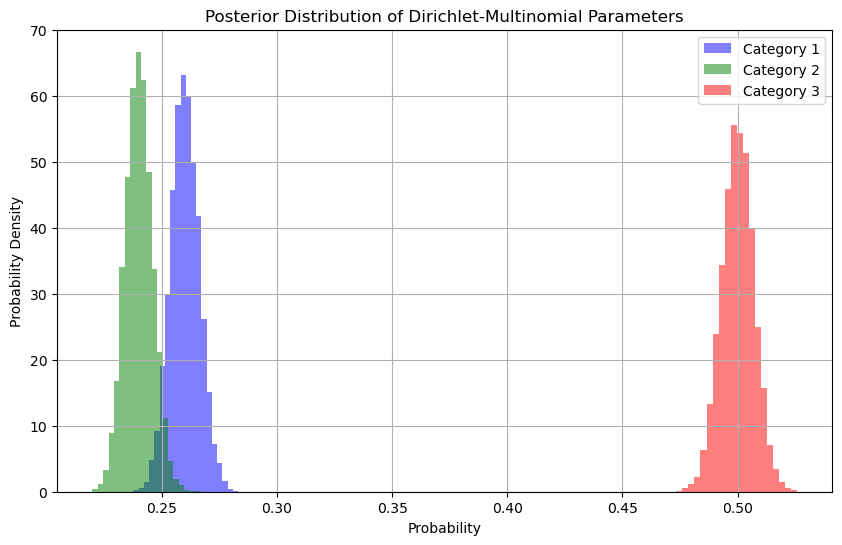

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import dirichlet, multinomial

# Step 1: Initialize parameters
alpha_initial = np.ones(3)  # Initial concentration parameters (e.g., for a 3-category problem)
n_trials = 10  # Number of trials

# Step 2: E-step (Expectation)
def calculate_expected_values(data, alpha):
    # Calculate the expected values of the latent variable (the probability vector)
    expected_values = []
    for observation in data:
        expected_value = (observation + alpha) / (np.sum(observation) + np.sum(alpha))
        expected_values.append(expected_value)
    return expected_values

# Step 3: M-step (Maximization)
def update_parameters(data, expected_values, alpha):
    # Update the concentration parameters (alpha) using the expected values
    alpha_updated = np.sum(np.array(data).T @ expected_values, axis=1) + alpha
    return alpha_updated

# Step 4: Convergence criterion
def has_converged(alpha_prev, alpha_updated, tol=1e-6):
    # Check if the parameter estimates have converged
    return np.all(np.abs(alpha_updated - alpha_prev) < tol)

# Step 5: EM algorithm
def fit_dirichlet_multinomial(data, alpha_initial, max_iterations=100, tol=1e-6):
    alpha = alpha_initial

    for iteration in range(max_iterations):
        # E-step
        expected_values = calculate_expected_values(data, alpha)

        # M-step
        alpha_updated = update_parameters(data, expected_values, alpha)

        # Check for convergence
        if has_converged(alpha, alpha_updated, tol):
            break

        alpha = alpha_updated

    return alpha

# Sample data (observed counts for each category)
data = np.array([[3, 2, 5], [4, 1, 5], [2, 3, 5], [3, 4, 3], [1, 2, 7]])

# Fit the Dirichlet-Multinomial distribution using EM
estimated_alpha = fit_dirichlet_multinomial(data, alpha_initial)

# Step 6: Use the estimated parameters to create a Dirichlet distribution
estimated_distribution = dirichlet(estimated_alpha)

# Plot the posterior distribution
samples = estimated_distribution.rvs(size=10000)  # Generate samples from the estimated Dirichlet distribution

# Visualize the posterior distribution using a histogram
plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'red']
for i in range(3):
    plt.hist(samples[:, i], bins=20, alpha=0.5, density=True, label=f'Category {i+1}', color=colors[i])

plt.xlabel('Probability')
plt.ylabel('Probability Density')
plt.title('Posterior Distribution of Dirichlet-Multinomial Parameters')
plt.legend()
plt.grid(True)
plt.show()
